# Reproducing Andersen+26 Figures

Here we provide code for reproducing Figures 3-16 in Andersen+26 (if you want the `pptx` files used to create Figure 1 + 2, contact the corresponding author, Bridget C. Andersen). 

If you wish to run through this notebook, you will need to download the digest for each simulation (see Table 11 in Andersen+26 and Step 5 in `Simulate_Run_PATH.ipynb`) at this Google Drive link: [link](https://drive.google.com/drive/folders/1Rv6koYfKJ7yQ5xYV666gIaMQ2wX0A6Tg?usp=drive_link). The files are descriptively named: 

`digest_<loc>_<intrinsic_offset_distribution>_<offset_prior>_<magnitude_prior>_<unseen_prior>_<catalog>.parquet`

For example, `digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet` is a simulation with the "CK" localization (see the top of Figure 6 of Andersen+26), an exponential intrinsic offset distribution, an exponential PATH offset prior, an inverse magnitude prior, a unseen prior of $P(U) = 0.15$, run with the `DECALs` catalog (the first entry in Table 11).

For the estimation of $P(U)$ (Figure 7), you will also need to download both of the pre-queried PATH catalogs at this Google Drive link: [link](https://drive.google.com/drive/folders/1PKqh8tnDLbtqIuGeoPFEEh60ovs8Zjw8?usp=drive_link)
- `Pan-STARRS`: download `catalog_dudxmmlss_hecate_Pan-STARRS.parquet`
- `DECaLs`: download `catalog_dudxmmlss_hecate_DECaL.parquet`

See Section 3.3 of Andersen+24 and Step 4 of `Simulate_Run_PATH.ipynb` for a description of these catalogs. Fair warning: these files are very large, 900 MB and 6.1 GB for `Pan-STARRS` and `DECaLs`, respectively. 


Download each of these files and save them in the directory defined by the `FRB_APATH` environmental variable.

In [7]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)
import matplotlib

import os
import pandas as pd
import numpy as np
from importlib.resources import files
from pathlib import Path

In [9]:
from frb.dm import prob_dmz
import scipy.stats as stats
from scipy.interpolate import CloughTocher2DInterpolator
from astropy.cosmology.realizations import Planck18 as cosmo
from astropy import units as u
from astropath.simulations import load_galaxy_catalog

In [3]:
# Set the directory where simulation data and catalogs are downloaded
os.environ['FRB_APATH'] = '/Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/'

## Figure 3

In [47]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet')
df = pd.read_parquet(fn)

In [13]:
# Load DMs from CHIME/FRB Catalog 1 with S/N > 12
fn = files('astropath.data') / 'frb_surveys' / 'chimefrbcat1.csv'
df_dr1 = pd.read_csv(fn)
chime_dms_eg = np.nanmean([df_dr1['dm_exc_ne2001'].values,df_dr1['dm_exc_ymw16'].values], axis=0)
chime_snrs = df_dr1['bonsai_snr']
threshold = 12.
chime_observed_dms_eg = chime_dms_eg[chime_snrs > threshold]
print(f"Observed CHIME/FRB DMs: N={len(chime_observed_dms_eg)}, median={np.median(chime_observed_dms_eg):.0f}" + r"$\rm pc cm^{-3}$")

Observed CHIME/FRB DMs: N=402, median=411$\rm pc cm^{-3}$


In [34]:
# Calculate KDE of Catalog 1 DMs
DMex = df['dmex_host'].values
kernel = stats.gaussian_kde(DMex)
dms = np.linspace(0., 3000, 500)
DMex_kde = kernel(dms)

# Grab simulated redshifts
zs = df['z_host'].values

In [30]:
# Load the survey-specific P(z,DM) grid
# First load grid to get z and DM arrays (they're the same for all)
grid_data = prob_dmz.grab_repo_grid('CHIME_pzdm.npz')
z = grid_data['z']
DM_EG = grid_data['DM']
grid = grid_data['pzdm']
pzDM = grid.flatten()

DM, Z = np.meshgrid(DM_EG, z)  # 2D grid for interpolation
interp = CloughTocher2DInterpolator(list(zip(Z.ravel(), DM.ravel())), grid.ravel(), fill_value=np.nan)
# Make new regular grid of z, dm coordinates
z_new_list = np.linspace(0, 2.5, 500)
dm_new_list = np.linspace(0, 4000, 500)
z_new, dm_new = np.meshgrid(z_new_list, dm_new_list)
Pz_dm_interp = interp(z_new, dm_new)
Pz_dm_interp[Pz_dm_interp < 0.] = 0.

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz


Text(0.5, 0, 'Redshift z')

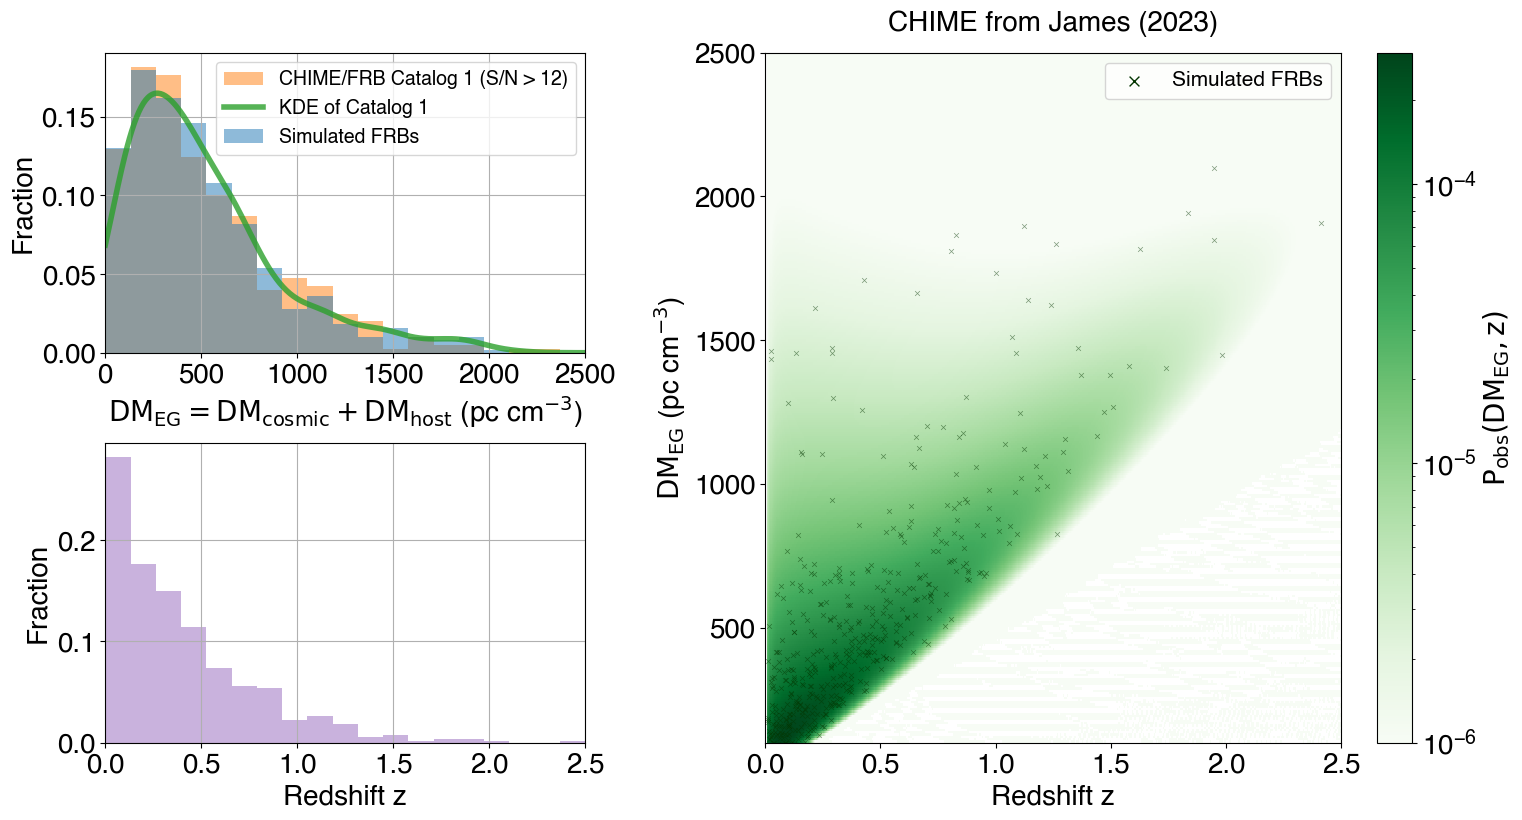

In [43]:
fig = plt.figure(figsize=(12, 6))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
height = 1/2.
sep_h = 0.15
width = 0.4
sep_w = 0.15
ax_z = (0., 0., width, height)
ax_dmeg = (0., (height+sep_h), width, height)
ax_pzdm = (width+sep_w, 0., 0.6, height*2+sep_h)

ax = plt.axes(ax_pzdm)
my_cmap = matplotlib.colormaps['Greens'] # copy the default cmap, cubehelix
# my_cmap.set_bad((0,0,0))
pc = ax.pcolormesh(
    z_new, dm_new, Pz_dm_interp, cmap=my_cmap, 
    norm=matplotlib.colors.LogNorm(vmin=1e-6), # vmin=1e-6, vmax=2e-4
    rasterized=True,
)
plt.colorbar(pc, label=r'$\rm P_{obs}(DM_{EG},z)$')
# plt.scatter(z_samp, DM_EG_samp, color='xkcd:lightish blue', alpha=.5, s=12, linewidth=0.5, edgecolor='xkcd:dark blue', rasterized=True)
plt.scatter(zs, DMex, marker='x', color='xkcd:dark green', alpha=.5, s=12, linewidth=0.5, rasterized=True, label='Simulated FRBs')
plt.xlim([0, 2.5])
plt.ylim([100, 2500])
plt.xlabel('Redshift z')
plt.ylabel(r'$\rm DM_{EG}$ (pc cm$^{-3}$)')#' = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.title(r'CHIME from James (2023)', fontsize=20, y=1.02) #  $\rm P_{obs}(z|DM_{EG})$
leg = plt.legend(fontsize=15)
for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_sizes([50])
    lh.set_linewidth([1])
    
ax = plt.axes(ax_dmeg)
bins = np.linspace(0,2500,20)
density = False
weights = np.ones_like(chime_observed_dms_eg) / float(len(chime_observed_dms_eg))
counts, bin_edges, _ = plt.hist(chime_observed_dms_eg, bins=bins, color=cycle[1], weights=weights, density=density, alpha=0.5, label='CHIME/FRB Catalog 1 (S/N > 12)')
bin_width = np.diff(bin_edges)[0]  # array of bin widths
N = len(DMex)
norm = N * bin_width  # one per bin
plt.plot(dms, DMex_kde * norm / float(len(DMex)), color=cycle[2], alpha=0.8, lw=4, label='KDE of Catalog 1')#  / np.nanmax(DMex_kde)*np.nanmax(hist[0])
weights = np.ones_like(DMex) / float(len(DMex))
hist = plt.hist(DMex, bins=bins, color=cycle[0], weights=weights, density=density, alpha=0.5, label='Simulated FRBs')
plt.xlim([0,2500])
plt.ylabel('Fraction')
plt.grid(zorder=1)
plt.legend(fontsize=14)
# _ = plt.yticks(np.arange(0, 1000+1, 500))
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')

ax = plt.axes(ax_z)
bins = np.linspace(0,2.5,20)
weights = np.ones_like(zs) / float(len(zs))
hist = plt.hist(zs, bins=bins, weights=weights, density=density, color=cycle[4], alpha=0.5)
plt.ylabel('Fraction')
plt.xlim([0,2.5])
plt.grid(zorder=1)
plt.xlabel(r'Redshift z')

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'frb_props_redo_norm.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 4

In [4]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet')
df = pd.read_parquet(fn)

In [5]:
# Load in the combined host catalog
combined_catalog_fn = os.path.join(os.getenv('FRB_APATH'), 'combined_HSC_PS1_HECATE_galaxies.parquet')
combined_catalog = pd.read_parquet(combined_catalog_fn)

In [6]:
df.keys()

Index(['ra_loc', 'dec_loc', 'true_ra', 'true_dec', 'host_ID', 'gal_off',
       'mag_host', 'ang_size_host', 'loc_off', 'FRB_ID', 'a', 'b', 'PA',
       'ra_host', 'dec_host', 'sep_best_host_arcsec', 'sep_host_loc_arcsec',
       'sep_host_loc_norm', 'sep_best_loc_arcsec', 'sep_best_loc_norm',
       'z_host', 'dmex_host', 'frb_mr', 'frb_Mr', 'ra_cand', 'dec_cand',
       'ang_size_cand', 'mag_cand', 'cand_ID', 'P_O', 'p_xO', 'P_Ox', 'P_Ux',
       'correct_association'],
      dtype='str')

In [10]:
# Get absolute magnitudes of 46 known FRB hosts
fn = files('astropath.data') / 'frb_surveys' / 'Lz_host_data.csv' # From Alexa Gordon, complete up to Shannon+24
df_known = pd.read_csv(fn)
# Scale mrs with z's to find distribution of Mrs
mrs = np.array(df_known['r-band'])
zs_mrs = np.array(df_known['redshift'])
# Get luminosity distance
ds = cosmo.luminosity_distance(zs_mrs).to(u.parsec).value
# Calculate absolute magnitudes
Mrs = mrs - 5. * np.log10(ds) + 5

# Calculate KDE of absolute magnitudes
kernel = stats.gaussian_kde(Mrs)
mags = np.linspace(-25., -15., 500)
Mr_kde = kernel(mags)

# Get simulated absolute magnitudes
Mrs_sim = df['frb_Mr']

# Get simulated apparent magnitudes
host_m_r = df['frb_mr']

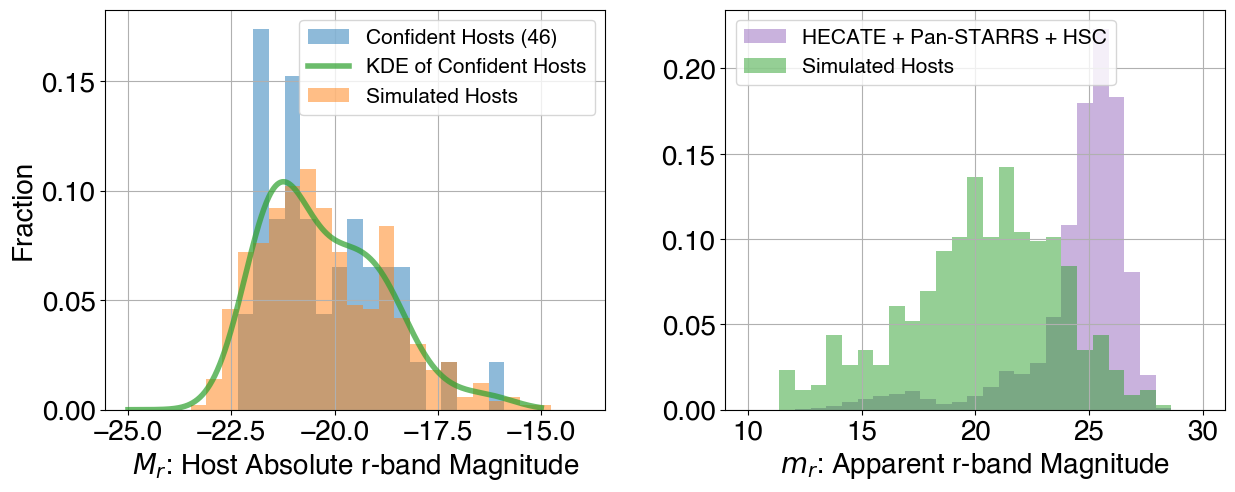

In [11]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.5
sep_w = 0.12
Mr_ax = (0., 0., width, 1.)
mr_ax = (width+sep_w, 0., width, 1.)

fig = plt.figure(figsize=(10,4))

ax = plt.axes(Mr_ax)
bins = np.linspace(-25, -14, 30)
weights = np.ones_like(Mrs) / float(len(Mrs))
counts, bin_edges, _ = plt.hist(Mrs, bins=bins, color=cycle[0], lw=4, alpha=0.5, weights=weights, density=False, label=f"Confident Hosts ({len(Mrs)})")
bin_width = np.diff(bin_edges)[0]  # array of bin widths
N = len(Mrs)
norm = N * bin_width  # one per bin
plt.plot(mags, Mr_kde * norm / float(len(Mrs)), color=cycle[2], lw=4, label='KDE of Confident Hosts', alpha=0.7)
weights = np.ones_like(Mrs_sim) / float(len(Mrs_sim))
hist = plt.hist(Mrs_sim, bins=bins, color=cycle[1], weights=weights, density=False, alpha=0.5, label='Simulated Hosts')
plt.xlabel('$M_r$: Host Absolute r-band Magnitude')
plt.ylabel('Fraction')
plt.legend(fontsize=15)
plt.grid(zorder=1)

ax = plt.axes(mr_ax)
bins = np.linspace(10, 30, 30)
inds = np.random.randint(low=0, high=len(combined_catalog), size=500000)
weights = np.ones_like(combined_catalog.iloc[inds]['mag']) / float(len(combined_catalog.iloc[inds]['mag']))
hist, bins, _ = plt.hist(combined_catalog.iloc[inds]['mag'], bins=bins, color=cycle[4], lw=4, alpha=0.5, density=False, weights=weights, label=f"HECATE + Pan-STARRS + HSC")
weights = np.ones_like(host_m_r) / float(len(host_m_r))
hist, bins, _ = plt.hist(host_m_r, bins=bins, color=cycle[2], lw=4, alpha=0.5, density=True, weights=weights, label=f"Simulated Hosts")
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.legend(fontsize=15, loc='upper left')
# plt.ylim([0,0.5])

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'Mr_distribution_redo_norm.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 5

In [34]:
from astropath.simulations import generate_frbs

In [4]:
# Load in simulations digest
fn = os.path.join(os.getenv('FRB_APATH'), 'digest_a25b2pa12_exponential_exp_inverse_pu0.15_catalog_dudxmmlss_hecate_DECaL.parquet')
df = pd.read_parquet(fn)

In [115]:
# Load in the combined host catalog
# 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet'
combined_catalog_fn = os.path.join(os.getenv('FRB_APATH'), 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet')
combined_catalog = pd.read_parquet(combined_catalog_fn)

In [10]:
# Load in the pre-queried galaxy catalog
fn = 'catalog_dudxmmlss_hecate_DECaL.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_DECaL.parquet


In [117]:
# Vectorized catalog identification (works for astropy Table or pandas DataFrame)
conditions = [
    ~np.isnan(combined_catalog['DECaL_ID'].astype(float)),
    ~np.isnan(combined_catalog['HSC_ID'].astype(float)),
    combined_catalog['SDSS_PHOTID'] != None,
]
choices = ['DECaL', 'HSC', 'HECATE']

orig_catalog = np.select(conditions, choices, default='')
orig_ras     = np.array(combined_catalog['ra'])
orig_decs    = np.array(combined_catalog['dec'])

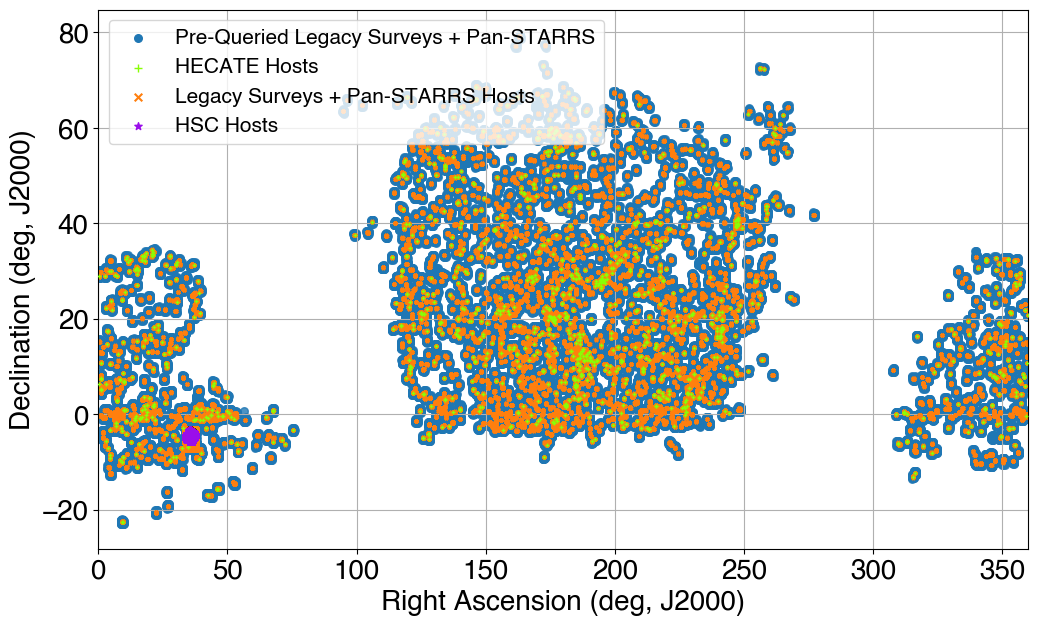

In [120]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig = plt.figure(figsize=(12,7))

plot_cat = path_catalog[::1000]
plt.scatter(plot_cat['ra'], plot_cat['dec'], color=cycle[0], s=30, alpha=0.8, label='Pre-Queried Legacy Surveys + Pan-STARRS', rasterized=True, zorder=1)
plt.scatter(orig_ras[orig_catalog == 'HECATE'], orig_decs[orig_catalog == 'HECATE'], color='xkcd:lime green', s=10, linewidths=1, alpha=1, marker='+', label='HECATE Hosts', rasterized=True, zorder=3)
plt.scatter(orig_ras[orig_catalog == 'DECaL'], orig_decs[orig_catalog == 'DECaL'], color=cycle[1], s=5, alpha=1, marker='x', label='Legacy Surveys + Pan-STARRS Hosts', rasterized=True, zorder=2)
plt.scatter(orig_ras[orig_catalog == 'HSC'], orig_decs[orig_catalog == 'HSC'], color='xkcd:violet', s=10, alpha=1, linewidths=1, marker='*', label='HSC Hosts', rasterized=True, zorder=4)
# plt.scatter(plot_cat['ra'], plot_cat['dec'], color='#AAAAAA', s=30, alpha=0.8, label='Pre-Queried Legacy Surveys + Pan-STARRS', rasterized=True)
# plt.scatter(orig_ras[orig_catalog == 'DECaL'], orig_decs[orig_catalog == 'DECaL'], color='#0077BB', s=10, alpha=1, marker='x', label='Legacy Surveys + Pan-STARRS Hosts', rasterized=True)
# plt.scatter(orig_ras[orig_catalog == 'HECATE'], orig_decs[orig_catalog == 'HECATE'], color='#EE7733', s=10, linewidths=1, alpha=1, marker='+', label='HECATE Hosts', rasterized=True)
# plt.scatter(orig_ras[orig_catalog == 'HSC'], orig_decs[orig_catalog == 'HSC'], color='#EE3377', s=10, alpha=1, linewidths=1, marker='*', label='HSC Hosts', rasterized=True)
plt.xlabel('Right Ascension (deg, J2000)') # amethyst
plt.ylabel('Declination (deg, J2000)')
lgnd = plt.legend(loc='upper left', fontsize=15)
plt.xlim([0,360])
plt.grid()
# Set a visible legend marker
for l in lgnd.legend_handles:
    l._sizes = [30]
    l._alpha = [1.]
    
# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'selected_hosts_by_catalog_recolor.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

## Figure 6

## Figure 7

## Figure 8

## Figure 9

## Figure 10

## Figure 11

## Figure 12

## Figure 13

## Figure 14

## Figure 15

## Figure 16